### Project Overview: Simulating Earth's Orbit and Energy Conservation

In this project, I modeled the orbital dynamics of the Earth around the Sun to observe the system's kinetic, potential, and total mechanical energy over time. Specifically, I chose to implement the Verlet integration method from scratch rather than relying on standard ODE solvers like `solve_ivp()`. This choice was deliberate; symplectic integrators like the Verlet method are specifically designed to preserve the physical properties of Hamiltonian systems, ensuring that total energy remains strictly conserved over long periods. 

---

### 1. Mathematical Foundation

The core of the simulation relies on Newton's law of universal gravitation. The equations of motion for the position $(x(t), y(t))$ of the Earth in its orbital plane are defined by the following second-order differential equations:

$$\frac{d^{2}x(t)}{dt^{2}}=-G\,M\,\frac{x(t)}{r^{3}}$$

$$\frac{d^{2}y(t)}{dt^{2}}=-G\,M\,\frac{y(t)}{r^{3}}$$

where $r=\sqrt{x^{2}+y^{2}}$ represents the distance between the Earth and the Sun.

---

### 2. Physical Constants and Initial Conditions

To ensure physical accuracy, I worked entirely in SI units. I defined a unified parameter tuple, `par`, structured precisely in the order (G, M, m) to pass cleanly into my functions:

*   **Gravitational Constant (G):** $6.6738 \times 10^{-11} \text{ m}^3\text{kg}^{-1}\text{s}^{-2}$
*   **Mass of the Sun (M):** $1.9891 \times 10^{30} \text{ kg}$
*   **Mass of the Earth (m):** $5.9722 \times 10^{24} \text{ kg}$

For the starting state of the simulation, I set the initial position vector to $\mathbf{r}_0 = (1.521 \times 10^{11}, 0) \text{ m}$ and the initial velocity vector to $\mathbf{v}_0 = (0, 2.9291 \times 10^4) \text{ m/s}$. 

---

### 3. Implementation Steps

I built the project in a modular way, breaking down the physics and the numerical integration into dedicated functions:

*   **The Integration Engine (`solve(par)`):** I implemented the Verlet method to solve the equations of motion. I set the time-step resolution to one hour and ran the simulation for a total period of three years (assuming a 365-day year). This function returns the position array $r(t)$ and velocity array $v(t)$ as a tuple.
*   **Potential Energy Calculation (`potentialEnergy(r, par)`):** I wrote this function to calculate the gravitational potential energy at any given position $r(t)$. Since this is a bound orbital system, these values are appropriately negative.
*   **Kinetic Energy Calculation (`kineticEnergy(v, par)`):** This function computes the kinetic energy of the Earth based on the velocity array $v(t)$.
*   **Testing and Verification:** I developed a testing suite to call `solve(par)` and automatically verify that the outputs of my kinetic and potential energy functions were mathematically sound and physically realistic.

---

### 4. Data Visualization and Analysis

Once the orbital data was generated, I analyzed the energy of the system by creating two distinct visualizations. Because I used SI units, the resulting energy values were massive—on the order of $10^{33} \text{ J}$. 

1.  **Superimposed Energy Plot:** I plotted the kinetic energy, potential energy, and total energy on a single canvas. This clearly visualized how the kinetic and potential energies continuously exchange and perfectly mirror each other as the Earth moves through its elliptical orbit, while the total energy line remains visibly flat.
2.  **Total Energy Conservation Plot:** To truly test the Verlet method, I created a second plot showing *only* the total energy as a function of time, zoomed in closely. This revealed the microscopic oscillating character characteristic of the Verlet algorithm, while proving that the mean total energy remained constant to an exceptionally high precision over the full three-year period.

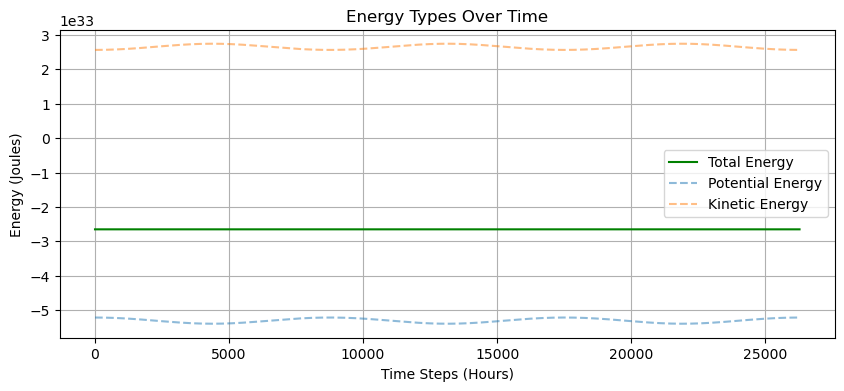

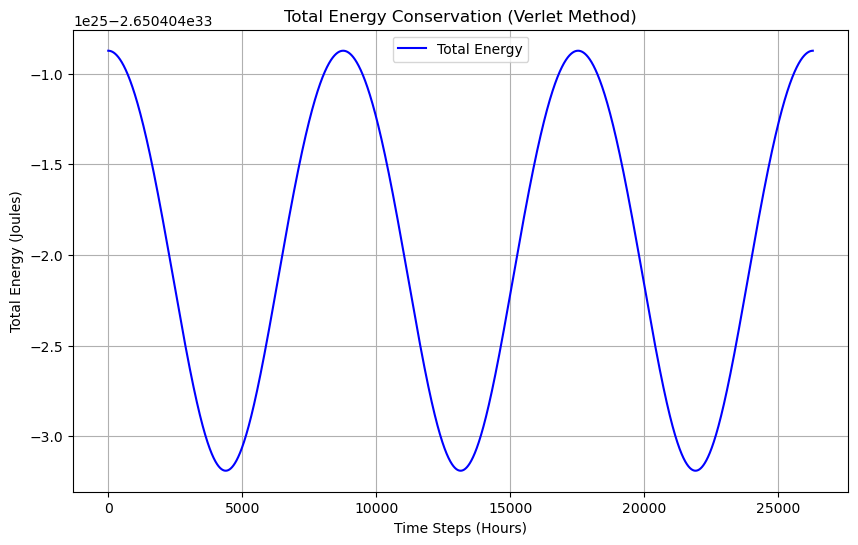

In [1]:
# Set up
import matplotlib.pyplot as plt
import numpy as np

G = 6.6738e-11
M = 1.9891e30
m = 5.9722e24
r_0 = np.array([1.521e11, 0.0])
v_0 = np.array([0.0, 2.9291e4])
par = (G, M, m)

def potentialEnergy(r, par):
    G, M, m = par
    r_mag = np.linalg.norm(r, axis=-1)
    return -G * M * m / r_mag

def kineticEnergy(v, par):
    G, M, m = par
    v_sq = np.sum(v**2, axis=-1)
    return 0.5 * m * v_sq

def get_acc(r, par):
    G, M, m = par
    r_mag = np.linalg.norm(r)
    return -G * M * r / (r_mag**3)

def solve(par, r_s, v_s):
    G, M, m = par

    # Constants
    dt = 3600.0 # Seconds
    years = 3
    num_steps = years * 365 * 24 # Years in hours (1 hour per step)
    
    # Initialization 
    r_history = np.zeros((num_steps + 1, 2))
    v_history = np.zeros((num_steps + 1, 2))
    r_current = r_s.copy()
    v_current = v_s.copy()
    
    # Store first state
    r_history[0] = r_current
    v_history[0] = v_current
    
    # Calculate initial acceleration
    a_current = get_acc(r_current, par)
    
    # Loop to 'integrate'
    for i in range(num_steps):
        r_next = r_current + v_current * dt + 0.5 * a_current * (dt**2)
        a_next = get_acc(r_next, par)
        v_next = v_current + 0.5 * (a_current + a_next) * dt
        
        # Store
        r_history[i+1] = r_next
        v_history[i+1] = v_next
        
        # Update for next iteration
        r_current = r_next
        v_current = v_next
        a_current = a_next
        
    return r_history, v_history

r_history, v_history = solve(par, r_0, v_0)
PE = potentialEnergy(r_history, par)
KE = kineticEnergy(v_history, par)
Total_Energy = PE + KE

# Plot 1 for energy
plt.figure(figsize=(10, 4))
plt.plot(Total_Energy, label='Total Energy', color='green')
plt.plot(PE, '--', label='Potential Energy', alpha=0.5)
plt.plot(KE, '--', label='Kinetic Energy', alpha=0.5)
plt.title("Energy Types Over Time")
plt.xlabel("Time Steps (Hours)")
plt.ylabel("Energy (Joules)")
plt.legend()
plt.grid(True)
plt.savefig("energy")
plt.show()

# Plot 2 for total energy conservation
plt.figure(figsize=(10, 6))
plt.plot(Total_Energy, label='Total Energy', color='blue')
plt.title("Total Energy Conservation (Verlet Method)")
plt.xlabel("Time Steps (Hours)")
plt.ylabel("Total Energy (Joules)")
plt.grid(True)
plt.legend()
plt.savefig("totalcons")
plt.show()